# SF Neighborhood Business Visualizations (2019–2025)

This notebook pulls the processed neighborhood parquet from GitHub (`ALL_openings_closings_by_neighs.parquet`) plus the demographics CSV and neighborhood geojson, to make maps/visualizations showing:
1. Business Net Change Heatmap by Neighborhood (2019–2025)
2. COVID Business Recovery by Neighborhood vs % POC
3. COVID Business Recovery by Neighborhood vs Median Income

## Setup

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

## Loading processed data from GitHub

In [2]:
gdf_raw = gpd.read_parquet('../../data/processed/ALL_openings_closings_by_neighs_year.parquet')
gdf_raw.head()

,neighborhood,geometry,year,closed,opened
0,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",2019,295.0,246.0
1,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",2020,221.0,206.0
2,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",2021,243.0,179.0
3,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",2022,255.0,179.0
4,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213...",2023,174.0,198.0


In [3]:
demo_df = pd.read_parquet('../../data/processed/demographics_by_neighs.parquet')

demo_df["pct_poc"] = 1 - demo_df["pct_white"]
demo_df = demo_df[["neighborhood", "median_income", "pct_poc"]].rename(
    columns={"neighborhood": "nhood"}
)

demo_df = demo_df[["nhood", "median_income", "pct_poc"]].copy()
demo_df.head()

,nhood,median_income,pct_poc
0,Bayview Hunters Point,99166.872614,0.923272
1,Bernal Heights,162466.201173,0.587381
2,Castro/Upper Market,203862.273066,0.337223
3,Chinatown,37973.447722,0.902009
4,Excelsior,109720.738362,0.847659


In [4]:
nbhd_gdf = gpd.read_file('../../data/raw/sf_neighborhoods.geojson').to_crs(epsg=4326)
print(nbhd_gdf.columns.tolist())
nbhd_gdf.head()

[':id', ':version', ':created_at', ':updated_at', 'nhood', 'geometry']


,:id,:version,:created_at,:updated_at,nhood,geometry
0,row-kat6_uieb_3jtd,rv-dbu2~hpud.6yya,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,Western Addition,"MULTIPOLYGON (((-122.42144 37.78557, -122.4213..."
1,row-z3d4_b3is_mfk7,rv-zi62-zgjg-kwse,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,West of Twin Peaks,"MULTIPOLYGON (((-122.46104 37.75096, -122.4605..."
2,row-xwem-yyxg.b4xp,rv-n2ba~749k.nkaj,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,Visitacion Valley,"MULTIPOLYGON (((-122.40385 37.71883, -122.4035..."
3,row-cyst-jf3k~s9cp,rv-emkr.suep.757p,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,Twin Peaks,"MULTIPOLYGON (((-122.44695 37.75655, -122.4459..."
4,row-zga5_xbxp_wavz,rv-dhre.4pg3-htj9,2023-10-17 18:30:10.955000+00:00,2023-10-17 18:30:10.955000+00:00,South of Market,"MULTIPOLYGON (((-122.40371 37.78404, -122.4027..."


## Joining dfs for visualization

In [5]:
# Filtering years and building pivot
gdf = gdf_raw[gdf_raw["year"].between(2019, 2025)].copy()
gdf = gdf.set_index(["neighborhood", "year"])

openings = gdf["opened"].unstack(fill_value=0)
closings = gdf["closed"].unstack(fill_value=0)

all_years = list(range(2019, 2026))
openings = openings.reindex(columns=all_years, fill_value=0)
closings = closings.reindex(columns=all_years, fill_value=0)

# Creating table with XX_year
op_named = openings.copy(); op_named.columns = [f"open_{y}"  for y in op_named.columns]
cl_named = closings.copy(); cl_named.columns = [f"close_{y}" for y in cl_named.columns]
neighborhood_table = op_named.join(cl_named, how="outer").fillna(0).astype(int)

In [6]:
# Creating net table for visualization and removing nbhds with fewer than 20 openings
min_openings = openings.min(axis=1)
valid = min_openings[min_openings >= 20].index

open_pivot_plot = openings.loc[valid]
close_pivot_plot = closings.loc[valid]
net_pivot_plot = open_pivot_plot - close_pivot_plot


In [7]:
# Combined table (resilience and demographics)
gdf_flat = gdf_raw[gdf_raw["year"].between(2019, 2025)].copy()

baseline = gdf_flat[gdf_flat["year"] == 2019].set_index("neighborhood")["opened"]
covid_closures = gdf_flat[gdf_flat["year"].between(2020, 2021)].groupby("neighborhood")["closed"].sum()
recovery_openings = gdf_flat[gdf_flat["year"].between(2022, 2024)].groupby("neighborhood")["opened"].sum()

rate_table = pd.DataFrame({
    "baseline": baseline,
    "closures_2020_21": covid_closures,
    "openings_2022_24": recovery_openings,
}).fillna(0)
rate_table["closure_rate"]  = rate_table["closures_2020_21"] / rate_table["baseline"]
rate_table["recovery_rate"] = rate_table["openings_2022_24"] / rate_table["baseline"]

rate_table_filtered = rate_table[rate_table["baseline"] >= 50].copy()
rate_table_filtered["resilience"] = rate_table_filtered["recovery_rate"] - rate_table_filtered["closure_rate"]

combined = rate_table_filtered.copy()
combined.index.name = "nhood"
combined = combined.join(demo_df.set_index("nhood")[["median_income", "pct_poc"]], how="left")
combined["median_income"] = pd.to_numeric(combined["median_income"], errors="coerce")
combined.head()

,baseline,closures_2020_21,openings_2022_24,closure_rate,recovery_rate,resilience,median_income,pct_poc
nhood,,,,,,,,
Bayview Hunters Point,703.0,1257.0,1839.0,1.788051,2.615932,0.827881,99166.872614,0.923272
Bernal Heights,329.0,612.0,777.0,1.860182,2.361702,0.501520,162466.201173,0.587381
Castro/Upper Market,437.0,880.0,1321.0,2.013730,3.022883,1.009153,203862.273066,0.337223
Chinatown,458.0,943.0,963.0,2.058952,2.102620,0.043668,37973.447722,0.902009
Excelsior,237.0,441.0,709.0,1.860759,2.991561,1.130802,109720.738362,0.847659


## Visualization 1: Net Change Heatmap (2019–2025)

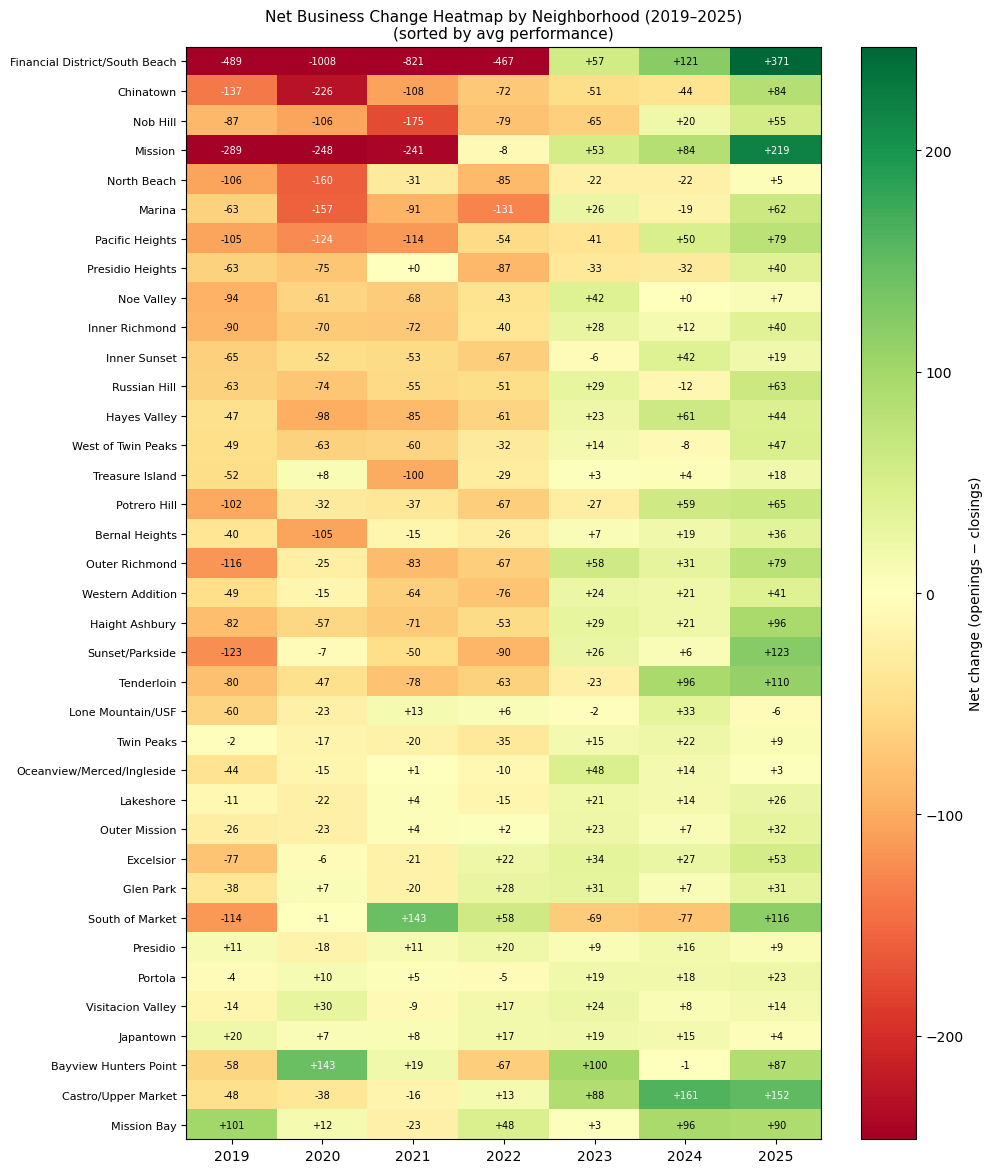

In [8]:
years = list(range(2019, 2026))

net_sorted = net_pivot_plot[years].copy()
net_sorted["avg"] = net_sorted[years].mean(axis=1)
net_sorted = net_sorted.sort_values("avg", ascending=True).drop(columns="avg")

fig3, ax3 = plt.subplots(figsize=(10, len(net_sorted) * 0.32))

vals = net_sorted.values[~np.isnan(net_sorted.values)]

vmin = np.percentile(vals, 2)
vmax = np.percentile(vals, 98)

# symmetric around zero (important since this is net change)
vabs = max(abs(vmin), abs(vmax))

im = ax3.imshow(net_sorted.values, aspect="auto", cmap="RdYlGn", vmin=-vabs, vmax=vabs)

ax3.set_xticks(range(len(years)))
ax3.set_xticklabels(years)
ax3.set_yticks(range(len(net_sorted)))
ax3.set_yticklabels(net_sorted.index, fontsize=8)
ax3.set_title(
    "Net Business Change Heatmap by Neighborhood (2019–2025)\n"
    "(sorted by avg performance)",
    fontsize=11
)

for i in range(len(net_sorted)):
    for j in range(len(years)):
        val = net_sorted.values[i, j]
        if not np.isnan(val):
            ax3.text(
                j, i, f"{int(val):+d}",
                ha="center", va="center", fontsize=7,
                color="white" if abs(val) > vabs * 0.5 else "black"
            )

plt.colorbar(im, ax=ax3, label="Net change (openings − closings)")
plt.tight_layout()
plt.savefig("../../outputs/neighborhood_net_change_heatmap.png", dpi=150)
plt.show()

## Visualization 2: Bivariate Choropleth: Recovery vs % POC (2019–2025)

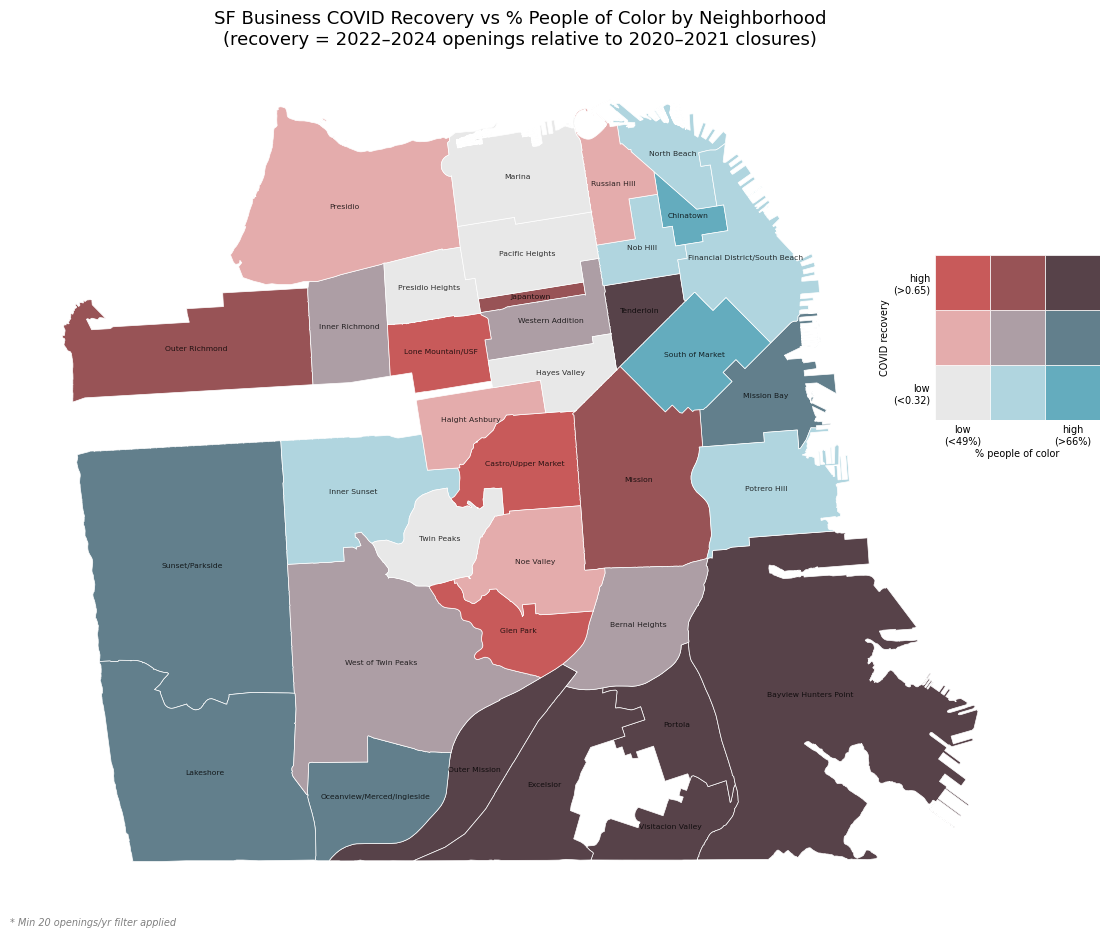

In [9]:
BIV_COLORS_POC = [
    ["#e8e8e8", "#b0d5df", "#64acbe"],
    ["#e4acac", "#ad9ea5", "#627f8c"],
    ["#c85a5a", "#985356", "#574249"],
]

combined_reset = combined.reset_index()
biv_poc = nbhd_gdf.merge(combined_reset, on="nhood", how="left")

biv_poc = biv_poc.dropna(subset=["resilience", "pct_poc"])

biv_poc["recovery_tertile"] = pd.qcut(
    biv_poc["resilience"],
    q=3,
    labels=[0, 1, 2]
).astype(int)

biv_poc["poc_tertile"] = pd.qcut(
    biv_poc["pct_poc"],
    q=3,
    labels=[0, 1, 2]
).astype(int)

biv_poc["biv_color"] = [
    BIV_COLORS_POC[recovery][poc]
    for recovery, poc in zip(biv_poc["recovery_tertile"], biv_poc["poc_tertile"])
]

recovery_breaks = biv_poc["resilience"].quantile([0.33, 0.67]).round(2).tolist()
poc_breaks = (biv_poc["pct_poc"].quantile([0.33, 0.67]) * 100).round(0).tolist()

fig, ax = plt.subplots(figsize=(13, 11))

for color, group in biv_poc.groupby("biv_color"):
    group.plot(ax=ax, color=color, edgecolor="white", linewidth=0.5)

for _, row in biv_poc.iterrows():
    if not row["geometry"].is_empty:
        x = row["geometry"].centroid.x
        y = row["geometry"].centroid.y
        ax.annotate(row["nhood"], xy=(x, y), fontsize=5.5,
                    ha="center", va="center", color="black", alpha=0.8)

ax.set_title(
    "SF Business COVID Recovery vs % People of Color by Neighborhood\n"
    "(recovery = 2022–2024 openings relative to 2020–2021 closures)",
    fontsize=13, pad=12
)
ax.axis("off")

legend_ax = fig.add_axes([0.82, 0.55, 0.15, 0.15])
legend_ax.set_xlim(0, 3)
legend_ax.set_ylim(0, 3)
legend_ax.set_aspect("equal")

for row_i in range(3):
    for col_i in range(3):
        legend_ax.add_patch(plt.Rectangle(
            (col_i, row_i), 1, 1,
            color=BIV_COLORS_POC[row_i][col_i],
            ec="white", lw=0.5
        ))

legend_ax.set_xticks([0.5, 1.5, 2.5])
legend_ax.set_xticklabels(["low\n(<" + str(int(poc_breaks[0])) + "%)", "", "high\n(>" + str(int(poc_breaks[1])) + "%)"], fontsize=7)
legend_ax.set_yticks([0.5, 1.5, 2.5])
legend_ax.set_yticklabels(
    ["low\n(<" + str(recovery_breaks[0]) + ")", "", "high\n(>" + str(recovery_breaks[1]) + ")"],
    fontsize=7
)
legend_ax.set_xlabel("% people of color", fontsize=7, labelpad=2)
legend_ax.set_ylabel("COVID recovery", fontsize=7, labelpad=2)
legend_ax.tick_params(length=0)

for spine in legend_ax.spines.values():
    spine.set_visible(False)

fig.text(0.12, 0.09, "* Min 20 openings/yr filter applied", fontsize=7, color="gray", style="italic")

plt.savefig("../../outputs/neighborhood_bivariate_poc_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualization 3: Bivariate Choropleth: Recovery vs Median Income (2019–2025)

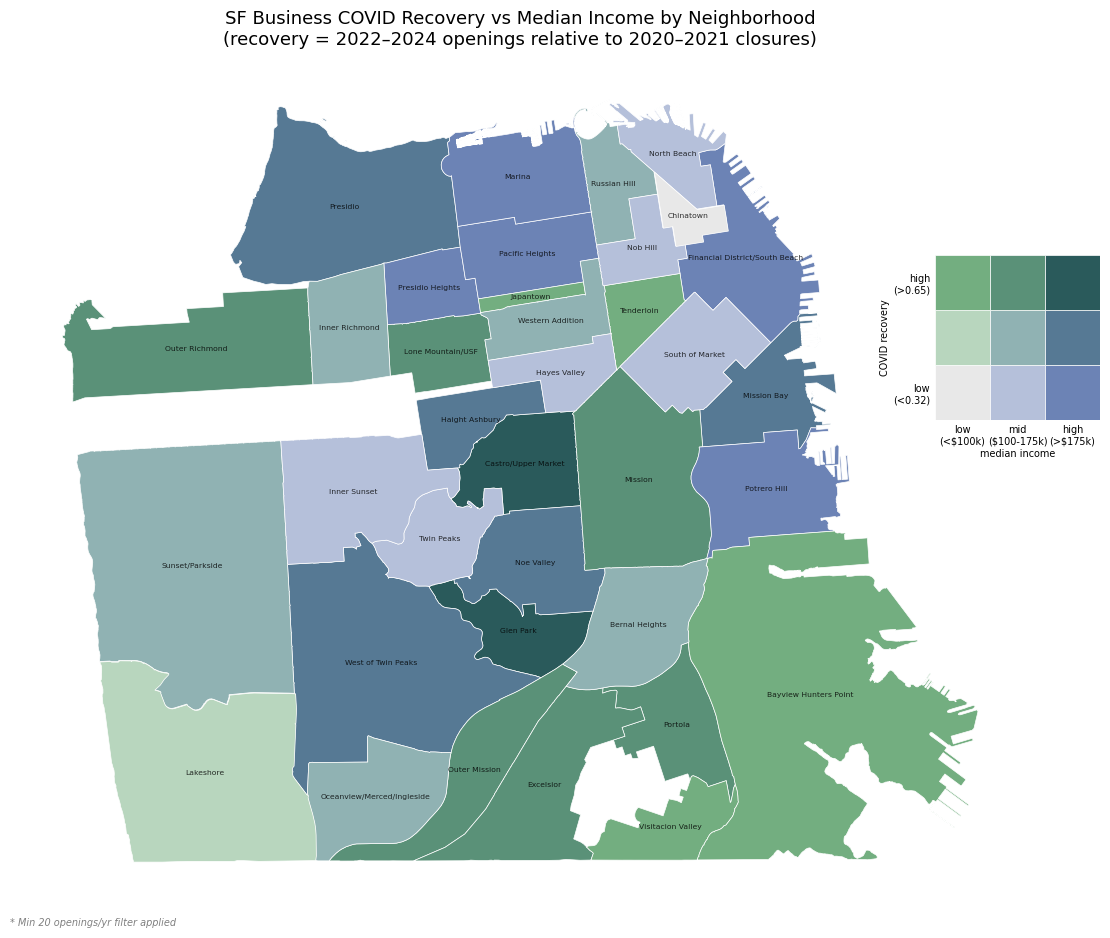

In [10]:
BIV_COLORS_INC = [
    ["#e8e8e8", "#b5c0da", "#6c83b5"],
    ["#b8d6be", "#90b2b3", "#567994"],
    ["#73ae80", "#5a9178", "#2a5a5b"],
]

combined_reset = combined.reset_index()
biv_income = nbhd_gdf.merge(combined_reset, on="nhood", how="left")

biv_income = biv_income.dropna(subset=["resilience", "median_income"])

biv_income["recovery_tertile"] = pd.qcut(
    biv_income["resilience"],
    q=3,
    labels=[0, 1, 2]
).astype(int)

biv_income["income_tertile"] = pd.cut(
    biv_income["median_income"],
    bins=[0, 100000, 175000, 999999999],
    labels=[0, 1, 2]
).astype(int)

biv_income["biv_color"] = [
    BIV_COLORS_INC[recovery][income]
    for recovery, income in zip(biv_income["recovery_tertile"], biv_income["income_tertile"])
]

recovery_breaks = biv_income["resilience"].quantile([0.33, 0.67]).round(2).tolist()

fig, ax = plt.subplots(figsize=(13, 11))

for color, group in biv_income.groupby("biv_color"):
    group.plot(ax=ax, color=color, edgecolor="white", linewidth=0.5)

for _, row in biv_income.iterrows():
    if not row["geometry"].is_empty:
        x = row["geometry"].centroid.x
        y = row["geometry"].centroid.y
        ax.annotate(row["nhood"], xy=(x, y), fontsize=5.5,
                    ha="center", va="center", color="black", alpha=0.8)

ax.set_title(
    "SF Business COVID Recovery vs Median Income by Neighborhood\n"
    "(recovery = 2022–2024 openings relative to 2020–2021 closures)",
    fontsize=13, pad=12
)
ax.axis("off")

legend_ax = fig.add_axes([0.82, 0.55, 0.15, 0.15])
legend_ax.set_xlim(0, 3)
legend_ax.set_ylim(0, 3)
legend_ax.set_aspect("equal")

for row_i in range(3):
    for col_i in range(3):
        legend_ax.add_patch(plt.Rectangle(
            (col_i, row_i), 1, 1,
            color=BIV_COLORS_INC[row_i][col_i],
            ec="white", lw=0.5
        ))

legend_ax.set_xticks([0.5, 1.5, 2.5])
legend_ax.set_xticklabels(["low\n(<$100k)", "mid\n($100-175k)", "high\n(>$175k)"], fontsize=7)
legend_ax.set_yticks([0.5, 1.5, 2.5])
legend_ax.set_yticklabels(
    ["low\n(<" + str(recovery_breaks[0]) + ")", "", "high\n(>" + str(recovery_breaks[1]) + ")"],
    fontsize=7
)
legend_ax.set_xlabel("median income", fontsize=7, labelpad=2)
legend_ax.set_ylabel("COVID recovery", fontsize=7, labelpad=2)
legend_ax.tick_params(length=0)

for spine in legend_ax.spines.values():
    spine.set_visible(False)

fig.text(0.12, 0.09, "* Min 20 openings/yr filter applied", fontsize=7, color="gray", style="italic")

plt.savefig("../../outputs/neighborhood_bivariate_income_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()